# 1. Project Overview


BasketHealthAI

Vision-AI system for grocery basket analysis using YOLOv8, SKU mapping, health scoring, and recommendation generation.


| Component      | Description               |
| -------------- | ------------------------- |
| Detection      | YOLOv8                    |
| Classes        | 7                         |
| Dataset        | NIT Patna + Custom Images |
| Scoring        | Rule-Based                |
| Recommendation | Category-Based            |




# System Architecture

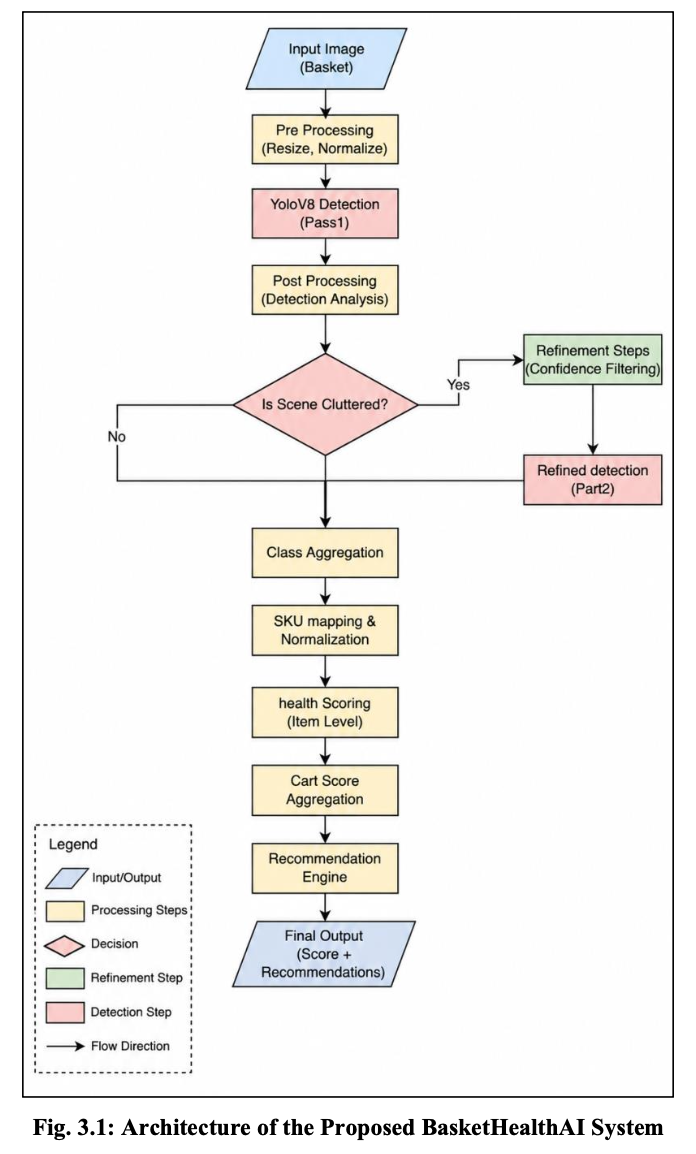

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
!pip install ultralytics
from ultralytics import YOLO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.3 MB/s eta 0:00:00


In [7]:
# ============================================
# 1) LOAD MODEL + SCORED SKU FILE (V3)
# ============================================
from ultralytics import YOLO
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

MODEL_PATH = "/content/drive/MyDrive/final_year_project/custom_od_project/final_runs/final_remapped_7class_e1002/weights/best.pt"
CSV_PATH = "/content/drive/MyDrive/final_year_project/custom_od_project/sku_mapping/sku_health_scored_v3.csv"

model = YOLO(MODEL_PATH)
sku_df = pd.read_csv(CSV_PATH)
sku_df["norm_name"] = sku_df["raw_name"].astype(str).str.lower().str.replace("_", " ", regex=False)

class_names = {
    0: "salty_snacks_fried",
    1: "sweet_biscuits_bakery",
    2: "instant_processed_foods",
    3: "sugary_drinks",
    4: "chocolate_confectionery",
    5: "icecream_frozen_desserts",
    6: "staples_cereals",
}

class_default_scores = {
    "salty_snacks_fried": 2.5,
    "sweet_biscuits_bakery": 3.5,
    "instant_processed_foods": 2.5,
    "sugary_drinks": 2.0,
    "chocolate_confectionery": 2.5,
    "icecream_frozen_desserts": 2.5,
    "staples_cereals": 7.5,
    "dairy_products": 6.5,
    "water": 10.0,
    "bread_refined": 4.5,
    "spreads_sugary_fatty": 3.0,
}

class_reasons = {
    "salty_snacks_fried": "fried snack category, likely high salt and low fiber",
    "sweet_biscuits_bakery": "refined flour and sugar-heavy bakery category",
    "instant_processed_foods": "processed instant food category, likely high sodium",
    "sugary_drinks": "sweetened beverage category with low satiety",
    "chocolate_confectionery": "high sugar confectionery category",
    "icecream_frozen_desserts": "dessert category with sugar/fat load",
    "staples_cereals": "staple category with better base nutrition potential",
    "dairy_products": "plain dairy category with better protein/calcium profile",
    "water": "hydration-friendly no-calorie beverage",
    "bread_refined": "refined bread category with lower fiber",
    "spreads_sugary_fatty": "spread category likely high in sugar or fat",
}

# ============================================
# 2) DEFAULT SUBTYPE PER DETECTED CLASS
#    (used because YOLO gives class, not subtype)
# ============================================
default_subtype_map = {
    "salty_snacks_fried": "chips",
    "sweet_biscuits_bakery": "cream_biscuit",
    "instant_processed_foods": "noodles",
    "sugary_drinks": "soft_drink",
    "chocolate_confectionery": "chocolate",
    "icecream_frozen_desserts": "icecream",
    "staples_cereals": "breakfast_cereal",
    "dairy_products": "milk",
    "water": "water",
    "bread_refined": "bread",
}

# ============================================
# 3) SUBTYPE-AWARE RECOMMENDATION TERMS
# ============================================
subtype_recommendations = {
    "chips": ["khakhra", "roasted makhana", "roasted chana"],
    "namkeen": ["roasted chana", "khakhra", "roasted peanuts"],
    "makhana": ["plain roasted makhana", "khakhra", "roasted chana"],
    "peanuts": ["roasted peanuts", "roasted chana", "khakhra"],
    "khakhra": ["khakhra", "roasted chana", "roasted makhana"],
    "general_snack": ["khakhra", "roasted chana", "roasted makhana"],

    "soft_drink": ["water", "zero sugar", "buttermilk"],
    "fruit_drink": ["coconut water", "water", "unsweetened"],
    "energy_drink": ["water", "coconut water", "buttermilk"],
    "sweet_dairy_drink": ["plain buttermilk", "unsweetened lassi", "milk"],
    "general_drink": ["water", "buttermilk", "unsweetened"],

    "noodles": ["oats", "poha", "upma"],
    "pasta": ["whole wheat pasta", "oats pasta", "vermicelli"],
    "soup": ["plain soup", "oats soup", "homestyle soup"],
    "quick_meal": ["oats", "dalia", "poha"],
    "general_instant": ["oats", "poha", "dalia"],

    "cream_biscuit": ["digestive", "oats biscuit", "cracker"],
    "cracker": ["multigrain cracker", "oats cracker", "high fiber"],
    "cookie": ["oats biscuit", "digestive", "plain biscuit"],
    "cake": ["rusk", "plain biscuit", "oats biscuit"],
    "rusk": ["whole wheat rusk", "cracker", "digestive"],
    "general_biscuit": ["digestive", "oats biscuit", "cracker"],

    "chocolate": ["dark chocolate", "nuts", "dates"],
    "candy": ["dates", "raisins", "nuts"],
    "general_confectionery": ["dark chocolate", "dates", "nuts"],

    "icecream": ["plain yogurt", "curd", "unsweetened yogurt"],

    "breakfast_cereal": ["oats", "muesli", "multigrain"],
    "flour": ["multigrain atta", "ragi flour", "bajra flour"],
    "grain_base": ["brown rice", "dalia", "oats"],
    "pulses": ["dal", "chana", "rajma"],
    "nuts_dryfruit": ["almonds", "walnuts", "mixed nuts"],

    "milk": ["plain milk", "curd", "paneer"],
    "curd_yogurt": ["plain curd", "yogurt", "buttermilk"],
    "paneer": ["paneer", "curd", "milk"],
    "cheese": ["paneer", "curd", "milk"],
    "butter": ["paneer", "curd", "milk"],
}

# ============================================
# 4) HELPERS
# ============================================
def get_candidates_from_terms(terms, top_k=3):
    parts = []
    for term in terms:
        sub = sku_df[sku_df["norm_name"].str.contains(term, na=False)].copy()
        parts.append(sub)

    if not parts:
        return []

    out = pd.concat(parts).drop_duplicates(subset=["raw_name"])
    out = out.sort_values(["health_score", "raw_name"], ascending=[False, True]).head(top_k)

    return out[["raw_name", "mapped_class", "subtype", "health_score", "risk_level"]].to_dict(orient="records")

def recommend_from_subtype(subtype, mapped_class=None, top_k=3):
    terms = subtype_recommendations.get(subtype, [])
    recs = get_candidates_from_terms(terms, top_k=top_k)

    if len(recs) >= top_k:
        return recs

    if mapped_class:
        fallback = sku_df[sku_df["mapped_class"] == mapped_class].copy()
        fallback = fallback.sort_values(["health_score", "raw_name"], ascending=[False, True]).head(top_k)
        return fallback[["raw_name", "mapped_class", "subtype", "health_score", "risk_level"]].to_dict(orient="records")

    return recs

def get_recommendations_final(detected_class, top_k=3):
    subtype = default_subtype_map.get(detected_class, "general")
    recs = recommend_from_subtype(subtype, mapped_class=detected_class, top_k=top_k)
    return {
        "class": detected_class,
        "subtype": subtype,
        "recommendations": recs
    }

def final_cart_analysis(detected_classes):
    counts = Counter(detected_classes)

    item_outputs = []
    scores = []

    for cls, count in counts.items():
        rec = get_recommendations_final(cls)
        base_score = class_default_scores.get(cls, 5.0)

        item_outputs.append({
            "class": cls,
            "count": count,
            "score": base_score,
            "reason": class_reasons.get(cls, "class-based health reasoning"),
            "subtype": rec["subtype"],
            "recommendations": rec["recommendations"]
        })

        scores.extend([base_score] * count)

    cart_score = round(sum(scores) / len(scores), 2) if scores else 0

    if cart_score < 3:
        label = "Unhealthy cart"
    elif cart_score < 6:
        label = "Moderate cart"
    else:
        label = "Better cart"

    return cart_score, label, item_outputs

def print_final_output(cart_score, label, items):
    print("=" * 70)
    print(f"CART SCORE: {cart_score}/10 → {label}")
    print("=" * 70)

    for item in items:
        print(f"\nDetected: {item['class']} (x{item['count']})")
        print(f"Assumed Subtype: {item['subtype']}")
        print(f"Health Score: {item['score']}/10")
        print(f"Reason: {item['reason']}")
        print("Better Alternatives:")
        for r in item["recommendations"]:
            print(f"  • {r['raw_name']} ({r['subtype']}) score={r['health_score']}")



Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [20]:
sku_df.head()

,sku_id,raw_name,normalized_name,mapped_class,is_mapped,needs_review,image_path,health_score,risk_level,reason,subtype,norm_name
0,2,50 50 Gol Maal,50 50 gol maal,sweet_biscuits_bakery,1,0,NaN,3.5,moderate,refined flour and sugar-heavy bakery item; sco...,general_biscuit,50 50 gol maal
1,3,50 50 sweet and salty,50 50 sweet and salty,sweet_biscuits_bakery,1,0,NaN,3.5,moderate,refined flour and sugar-heavy bakery item; sco...,general_biscuit,50 50 sweet and salty
2,4,50 50 top,50 50 top,sweet_biscuits_bakery,1,0,NaN,3.5,moderate,refined flour and sugar-heavy bakery item; sco...,general_biscuit,50 50 top
3,5,5Star_Bites_Cadbury,5star bites cadbury,chocolate_confectionery,1,0,NaN,2.3,high_risk,high sugar / confectionery product; score=2.5/10,chocolate,5star bites cadbury
4,10,Aashirvaad_Besan,aashirvaad besan,staples_cereals,1,0,NaN,8.1,healthiest,staple or cereal product with relatively bette...,flour,aashirvaad besan


In [16]:
# ============================================
# 5) TEST ON ONE IMAGE
# ============================================
IMG_PATH = '/content/drive/MyDrive/final_year_project/custom_od_project/extracted/dataset_yolo_remapped_7class_split/valid/images/bf81a9edb03ce1f6ad50e3829ff1638a_jpg.rf.2zvU9kd9iRu4eCwxRe7b.jpg'


# IMG_PATH = "/content/drive/MyDrive/final_year_project/custom_od_project/extracted/dataset_yolo_remapped_7class_split/valid/images/84be30e76777c786d559f2f44dbf5bb5_jpg.rf.j0AhauumXeEy0ETWypLO.jpg"  # change if needed

# IMG_PATH = '/content/drive/MyDrive/final_year_project/custom_od_project/extracted/dataset_yolo_remapped_7class_split/valid/images/1e15cc37fb062bfdc991b0c519e47ee9_jpg.rf.rBdltMVwxLkJn7UamGQF.jpg'



In [17]:
results = model.predict(
    source=IMG_PATH,
    imgsz=640,
    conf=0.25,
    iou=0.45,
    save=False
)

r = results[0]

detected_classes = []
if r.boxes is not None and len(r.boxes) > 0:
    for box in r.boxes:
        cls_id = int(box.cls.item())
        conf = float(box.conf.item())
        cls_name = class_names[cls_id]
        detected_classes.append(cls_name)
        print(f"Detected: {cls_name:28s} conf={conf:.3f}")
else:
    print("No detections found")




image 1/1 /content/drive/MyDrive/final_year_project/custom_od_project/extracted/dataset_yolo_remapped_7class_split/valid/images/bf81a9edb03ce1f6ad50e3829ff1638a_jpg.rf.2zvU9kd9iRu4eCwxRe7b.jpg: 640x384 10 salty_snacks_frieds, 3 sweet_biscuits_bakerys, 1 sugary_drinks, 135.3ms
Speed: 2.9ms preprocess, 135.3ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 384)
Detected: salty_snacks_fried           conf=0.954
Detected: salty_snacks_fried           conf=0.946
Detected: salty_snacks_fried           conf=0.853
Detected: sweet_biscuits_bakery        conf=0.851
Detected: salty_snacks_fried           conf=0.849
Detected: sweet_biscuits_bakery        conf=0.592
Detected: salty_snacks_fried           conf=0.530
Detected: sugary_drinks                conf=0.527
Detected: salty_snacks_fried           conf=0.455
Detected: salty_snacks_fried           conf=0.434
Detected: salty_snacks_fried           conf=0.382
Detected: salty_snacks_fried           conf=0.364
Detected: sweet_biscuits

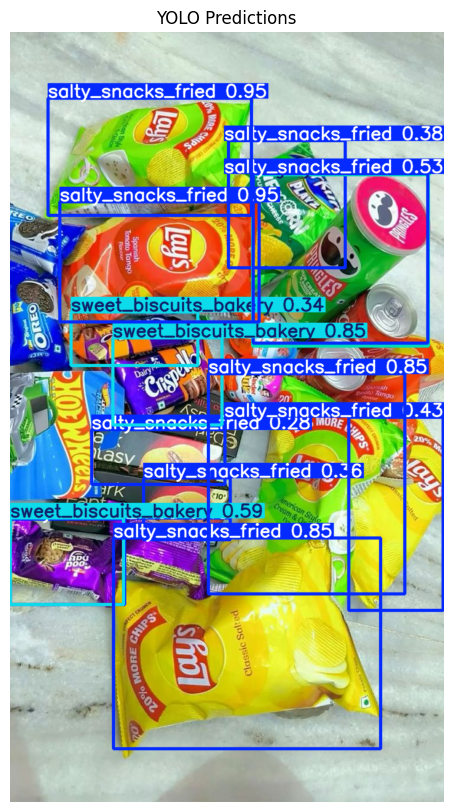

In [18]:
# Show annotated image
annotated = r.plot()
plt.figure(figsize=(10, 10))
plt.imshow(annotated[:, :, ::-1])
plt.axis("off")
plt.title("YOLO Predictions")
plt.show()

In [19]:
# Cart analysis
cart_score, label, items = final_cart_analysis(detected_classes)
print_final_output(cart_score, label, items)

CART SCORE: 2.68/10 → Unhealthy cart

Detected: salty_snacks_fried (x10)
Assumed Subtype: chips
Health Score: 2.5/10
Reason: fried snack category, likely high salt and low fiber
Better Alternatives:
  • PlainKhakhra_Talod (khakhra) score=7.1
  • JeeraKhakhra_Talod (khakhra) score=6.3
  • Khakhra_ShantaG (khakhra) score=6.3

Detected: sweet_biscuits_bakery (x3)
Assumed Subtype: cream_biscuit
Health Score: 3.5/10
Reason: refined flour and sugar-heavy bakery category
Better Alternatives:
  • Biscuit_Cracker_NutriChoice_Britannia (cracker) score=4.7
  • Biscuit_Nutrichoice_Cracker_Britannia (cracker) score=4.7
  • Cracker_NutriChoiceDigestive_Britannia (cracker) score=4.7

Detected: sugary_drinks (x1)
Assumed Subtype: soft_drink
Health Score: 2.0/10
Reason: sweetened beverage category with low satiety
Better Alternatives:
  • AlkalineWater_EvocusH20 (water) score=10.0
  • CarbonatedWater_Kinley (water) score=10.0
  • MineralWater_Kinley (water) score=10.0
